# EDA

# EDA = Exploratory Data Analysis



In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [2]:
df = pd.read_csv('titanic_data_updated.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

total 891 data and 12 columns (will be used as feature)

In [4]:
# randomly shuffle the data and see the features and target variable

df.sample(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
599,600,yes,first,"Duff Gordon, Sir. Cosmo Edmund (""Mr Morgan"")",male,49.0,1,0,PC 17485,56.9292,A20,C
813,814,no,third,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,NaN,S
426,427,yes,second,"Clarke, Mrs. Charles V (Ada Maria Winfield)",female,28.0,1,0,2003,26.0000,NaN,S
334,335,yes,first,"Frauenthal, Mrs. Henry William (Clara Heinshei...",female,NaN,1,0,PC 17611,133.6500,NaN,S
510,511,yes,third,"Daly, Mr. Eugene Patrick",male,29.0,0,0,382651,7.7500,NaN,Q
165,166,yes,third,"Goldsmith, Master. Frank John William ""Frankie""",male,9.0,0,2,363291,20.5250,NaN,S


here some null values are found by running the above multiple times

# Input screening

In [5]:
# see the missing values

print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
# checking duplicates

df.duplicated().sum()

np.int64(0)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


#### Univarient analysis
- ekta column ke dhore analysis kora

<Axes: xlabel='Survived', ylabel='count'>

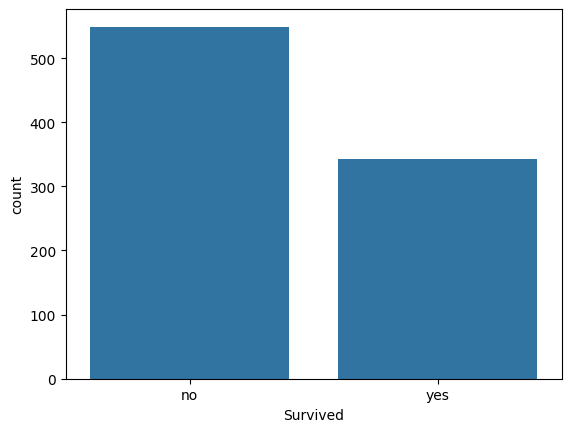

In [9]:
# for survived column
sns.countplot(x='Survived', data=df)

survival er rate imbalanced. no onek beshi

In [10]:
df['Survived'].value_counts()

Survived
no     549
yes    342
Name: count, dtype: int64

In [11]:
# to see the percentage of survived and not survived

df['Survived'].value_counts(normalize=True)

Survived
no     0.616162
yes    0.383838
Name: proportion, dtype: float64

([<matplotlib.patches.Wedge at 0x206a2b8a8d0>,
 [Text(-0.39257494735793463, 1.0275626067091557, 'no'),
  Text(0.3925749146953058, -1.0275626191877425, 'yes')],
 [Text(-0.21413178946796432, 0.5604886945686304, '61.6%'),
  Text(0.21413177165198496, -0.5604887013751322, '38.4%')])

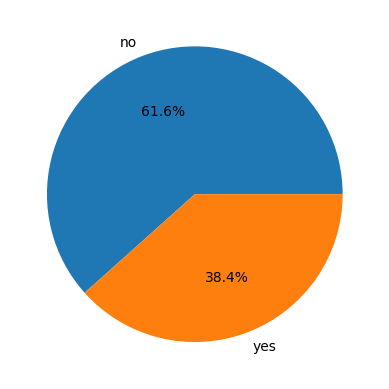

In [12]:
import matplotlib.pyplot as plt
survived_count = df['Survived'].value_counts()
plt.pie(survived_count, labels=survived_count.index, autopct='%1.1f%%')

<Axes: xlabel='Pclass', ylabel='count'>

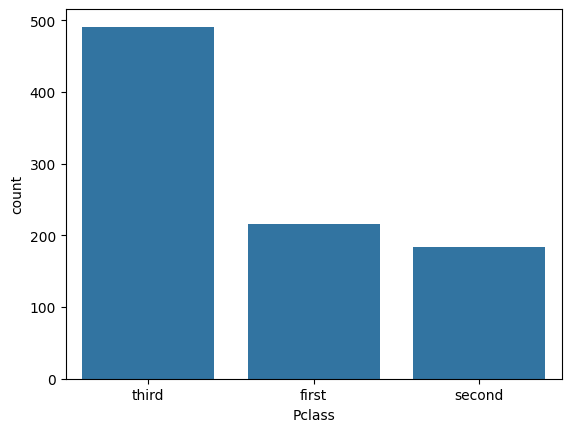

In [13]:
sns.countplot(data=df, x=df['Pclass'])

([<matplotlib.patches.Wedge at 0x206a4fda5d0>,
 [Text(-0.17571619097547903, 1.085874679799225, 'third'),
  Text(-0.5160760536623383, -0.9714244730478574, 'first'),
  Text(0.8765111790709129, -0.6646263258130227, 'second')],
 [Text(-0.09584519507753402, 0.5922952798904862, '55.1%'),
  Text(-0.2814960292703663, -0.5298678943897404, '24.2%'),
  Text(0.47809700676595246, -0.3625234504434669, '20.7%')])

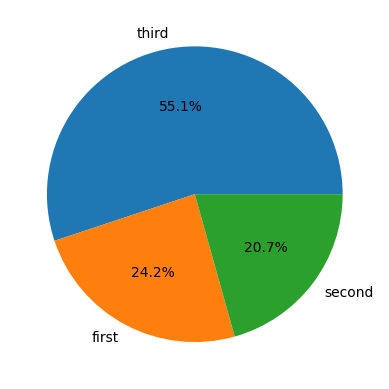

In [14]:
val_count = df['Pclass'].value_counts()

plt.pie(val_count,labels=val_count.index, autopct='%1.1f%%')

In [15]:
df['Pclass'].value_counts(normalize=True)

Pclass
third     0.551066
first     0.242424
second    0.206510
Name: proportion, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

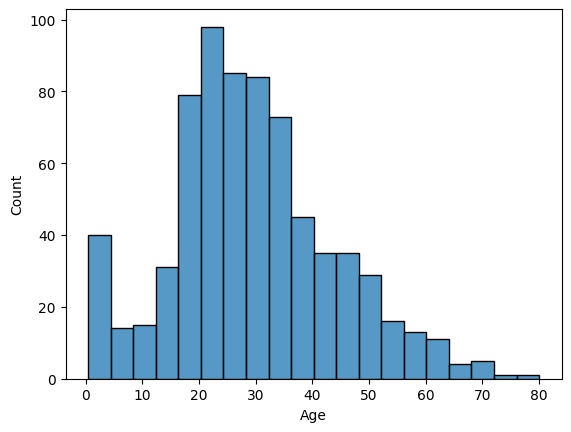

In [16]:
# univarient analysis for numerical columns
sns.histplot(data=df, x='Age', bins=20)

<Axes: xlabel='Age', ylabel='Density'>

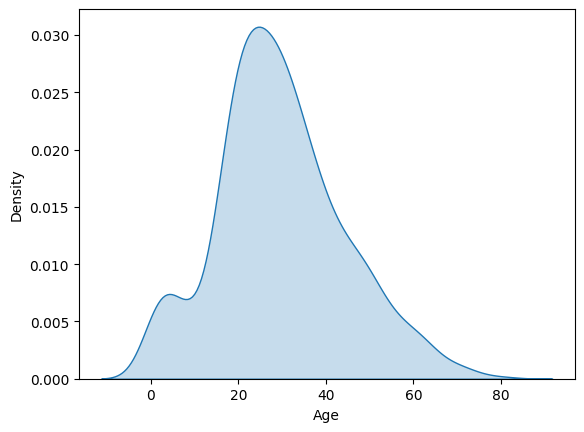

In [17]:
sns.kdeplot(data=df, x="Age", fill=True)


<Axes: xlabel='Fare', ylabel='Count'>

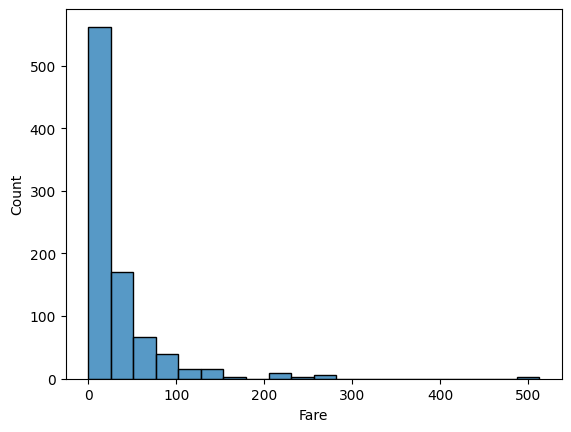

In [18]:
sns.histplot(data=df, x='Fare', bins=20)

C:\Users\User\AppData\Local\Temp\ipykernel_34020\1785776946.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='Fare', shade=True)


<Axes: xlabel='Fare', ylabel='Density'>

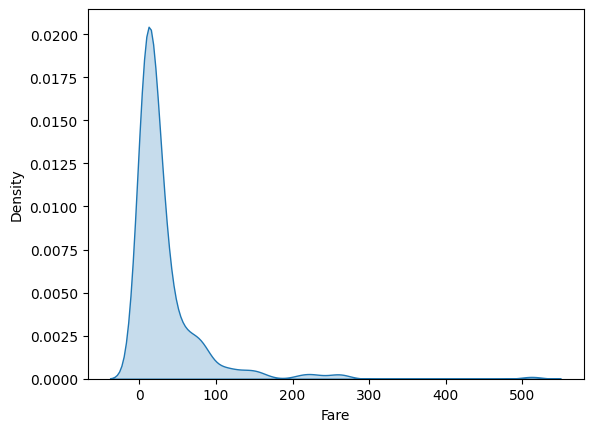

In [19]:
sns.kdeplot(data=df, x='Fare', shade=True)

<Axes: ylabel='Fare'>

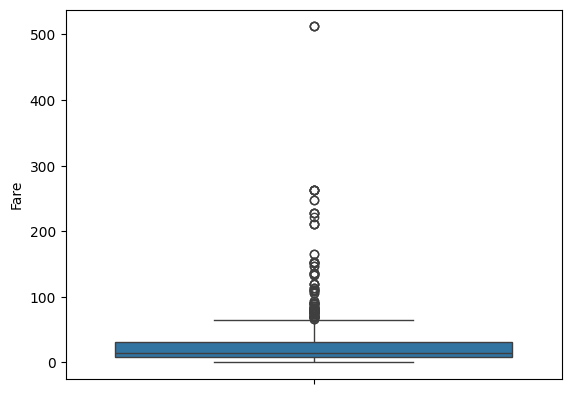

In [20]:
sns.boxplot(df['Fare'])

# Module 02: Multivariate Analysis

<Axes: xlabel='Sex', ylabel='count'>

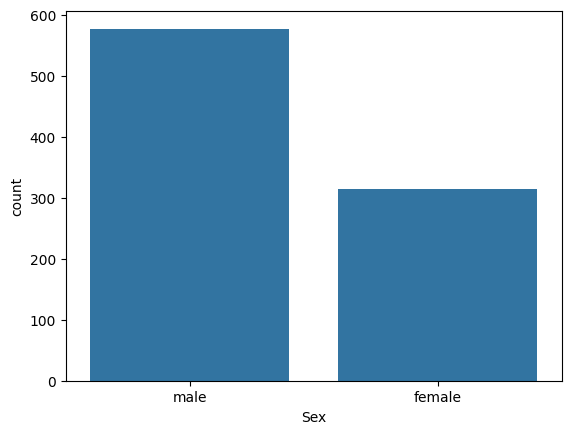

In [21]:
# univariate:
sns.countplot(data=df, x='Sex')

<Axes: xlabel='Sex', ylabel='count'>

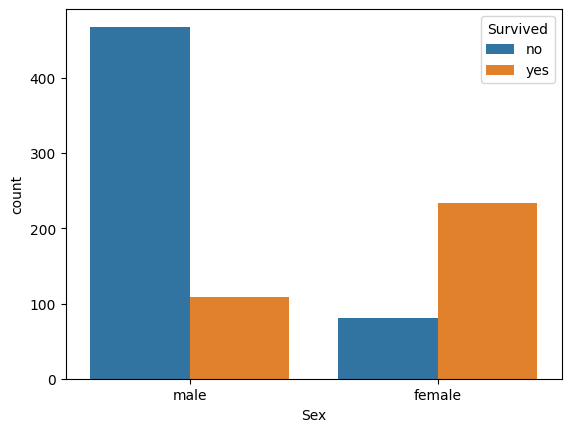

In [22]:
# multivarient:
sns.countplot(data=df,x=df['Sex'], hue=df['Survived'])

In [23]:
gender_split = df.groupby('Sex')['Survived'].value_counts()        # splits the data: male and female
print(gender_split)

Sex     Survived
female  yes         233
        no           81
male    no          468
        yes         109
Name: count, dtype: int64


In [24]:
gender_split = df.groupby('Sex')['Survived'].value_counts(normalize=True)        # splits the data: male and female
print(gender_split)

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64


<Axes: xlabel='Pclass', ylabel='count'>

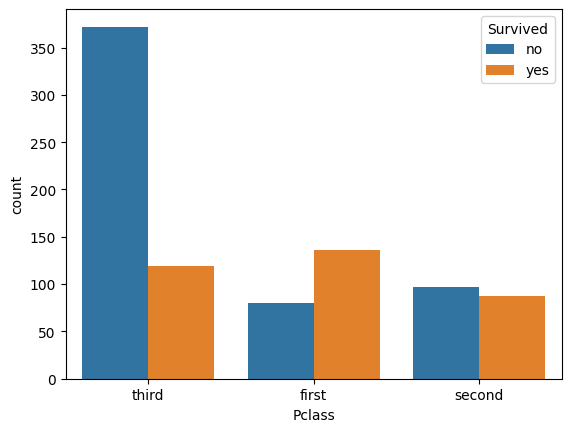

In [25]:
sns.countplot(data=df, x='Pclass', hue='Survived')

In [26]:
Pclass_split = df.groupby('Pclass')['Survived'].value_counts(normalize=True)        # splits the data: male and female
print(Pclass_split)

Pclass  Survived
first   yes         0.629630
        no          0.370370
second  no          0.527174
        yes         0.472826
third   no          0.757637
        yes         0.242363
Name: proportion, dtype: float64


ekhane 3rd class e survival rate onek kom, so model train test korar somoy statify kora lagbe

<Axes: xlabel='Pclass', ylabel='Fare'>

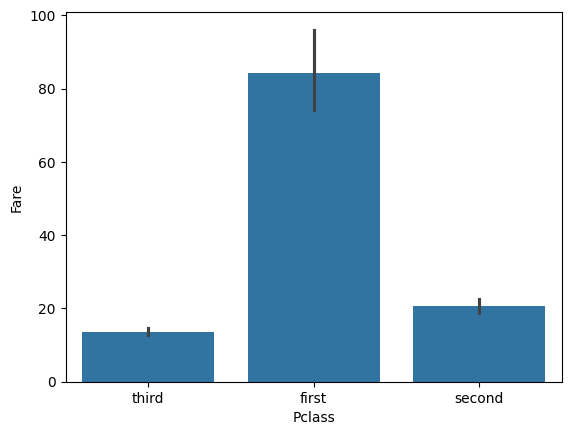

In [27]:
# observe mean using bar plot
sns.barplot(data=df, x='Pclass', y='Fare')

<Axes: xlabel='Survived', ylabel='Age'>

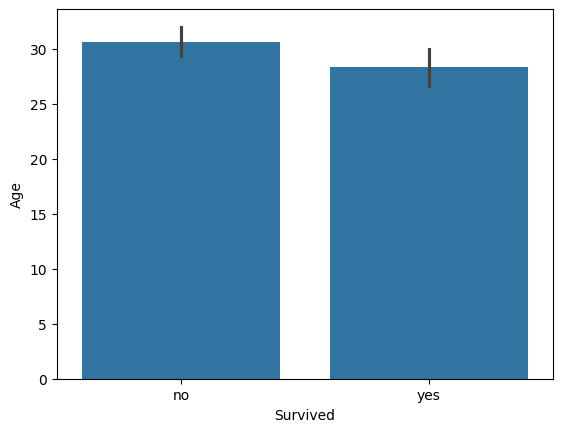

In [28]:
sns.barplot(data=df, x='Survived', y='Age')

<Axes: xlabel='Survived', ylabel='Age'>

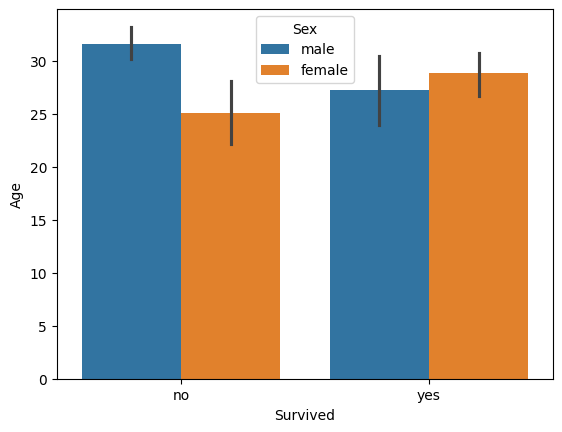

In [29]:
sns.barplot(data=df, x='Survived', y='Age', hue='Sex')

# Density Graph

KDE Plot

<Axes: xlabel='Age', ylabel='Density'>

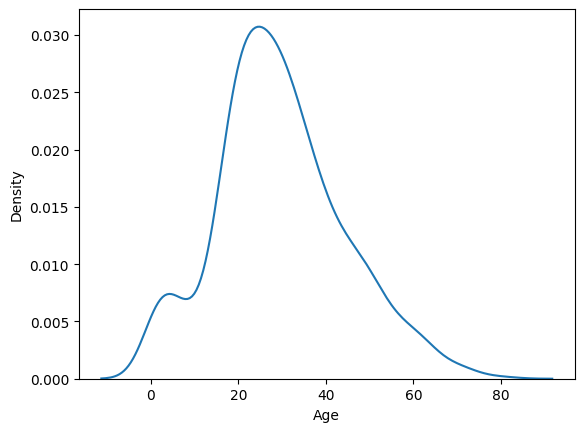

In [30]:
sns.kdeplot(data=df, x='Age')

<Axes: xlabel='Age', ylabel='Density'>

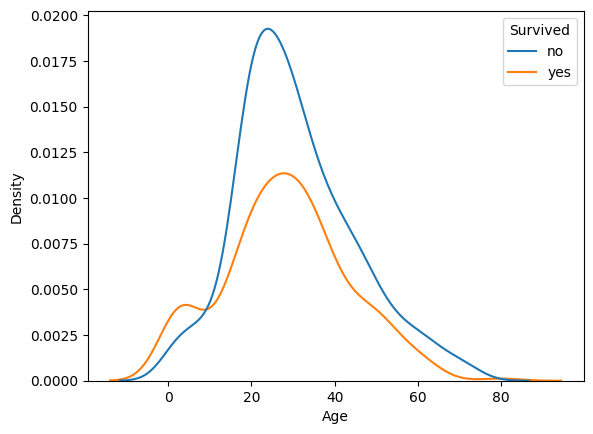

In [31]:
sns.kdeplot(data=df, x='Age', hue='Survived')

# Y data Profiling

it automates the eda and makes dinamic html file to edit / tune

In [32]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [33]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Titanic Data Profiling Report", )
profile.to_file("my_report.html")

C:\Users\User\AppData\Local\Temp\ipykernel_34020\2518019894.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 545.46it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [35]:
df.to_csv("titanic_data_updated.csv", index=False)